In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/home/user/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [7]:
data=pd.read_csv("residential_housing.csv")

In [8]:
numeric_df = data.select_dtypes(include='number')
numeric_df

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,349,0,0,0,0,0,0,2,2010,210000
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,0,60,0,0,0,0,2500,5,2010,266500
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,366,0,112,0,0,0,0,4,2010,142125


In [4]:

summary_data = print(data.describe(include="all"))
summary_data

                 Id   MSSubClass MSZoning  LotFrontage        LotArea Street  \
count   1460.000000  1460.000000     1460  1201.000000    1460.000000   1460   
unique          NaN          NaN        5          NaN            NaN      2   
top             NaN          NaN       RL          NaN            NaN   Pave   
freq            NaN          NaN     1151          NaN            NaN   1454   
mean     730.500000    56.897260      NaN    70.049958   10516.828082    NaN   
std      421.610009    42.300571      NaN    24.284752    9981.264932    NaN   
min        1.000000    20.000000      NaN    21.000000    1300.000000    NaN   
25%      365.750000    20.000000      NaN    59.000000    7553.500000    NaN   
50%      730.500000    50.000000      NaN    69.000000    9478.500000    NaN   
75%     1095.250000    70.000000      NaN    80.000000   11601.500000    NaN   
max     1460.000000   190.000000      NaN   313.000000  215245.000000    NaN   

       Alley LotShape LandContour Utili

In [5]:

Q1 = data.select_dtypes(include='number').quantile(0.25)
Q2 = data.select_dtypes(include='number').quantile(0.50)
Q3 = data.select_dtypes(include='number').quantile(0.75)

IQR = Q3 - Q1

print(f"Q1(First Quartile):{Q1}, Q2(Second Quartile): {Q2}, and Q3(Third quartile) : {Q3}")
print(f"Inter Quartile Range :{IQR}")

Q1(First Quartile):Id                  365.75
MSSubClass           20.00
LotFrontage          59.00
LotArea            7553.50
OverallQual           5.00
OverallCond           5.00
YearBuilt          1954.00
YearRemodAdd       1967.00
MasVnrArea            0.00
BsmtFinSF1            0.00
BsmtFinSF2            0.00
BsmtUnfSF           223.00
TotalBsmtSF         795.75
1stFlrSF            882.00
2ndFlrSF              0.00
LowQualFinSF          0.00
GrLivArea          1129.50
BsmtFullBath          0.00
BsmtHalfBath          0.00
FullBath              1.00
HalfBath              0.00
BedroomAbvGr          2.00
KitchenAbvGr          1.00
TotRmsAbvGrd          5.00
Fireplaces            0.00
GarageYrBlt        1961.00
GarageCars            1.00
GarageArea          334.50
WoodDeckSF            0.00
OpenPorchSF           0.00
EnclosedPorch         0.00
3SsnPorch             0.00
ScreenPorch           0.00
PoolArea              0.00
MiscVal               0.00
MoSold                5.00
YrSold   

In [7]:
data["LotArea"].describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

In [9]:
Q1 = data["LotArea"].quantile(0.25)
Q2 = data["LotArea"].quantile(0.50)
Q3 = data["LotArea"].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1(First Quartile):{Q1}, Q2(Second Quartile): {Q2}, and Q3(Third quartile) : {Q3}")
print(f"Inter Quartile Range :{IQR}")

Q1(First Quartile):7553.5, Q2(Second Quartile): 9478.5, and Q3(Third quartile) : 11601.5
Inter Quartile Range :4048.0


In [14]:
features = ['LotArea', 'GrLivArea', 'SalePrice']
iqr = {}

for col in features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    iqr[col] = Q3 - Q1

print(iqr)



{'LotArea': 4048.0, 'GrLivArea': 647.25, 'SalePrice': 84025.0}


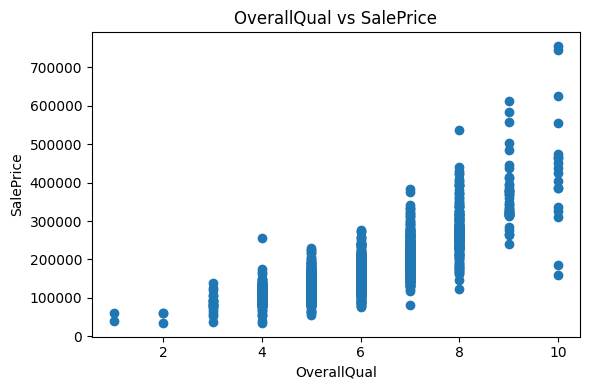

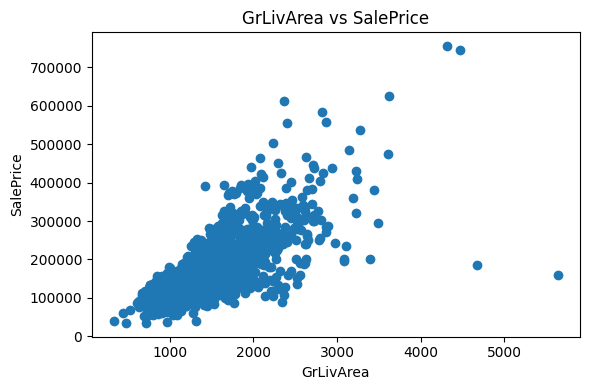

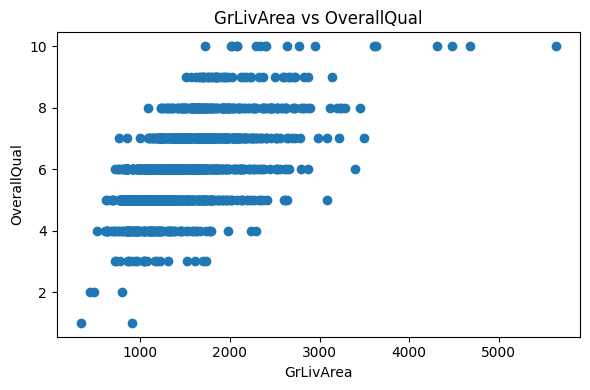

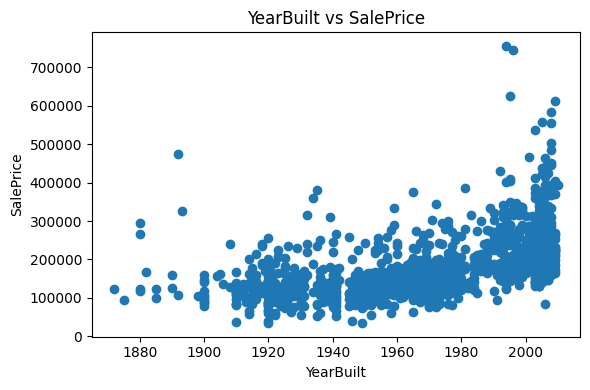

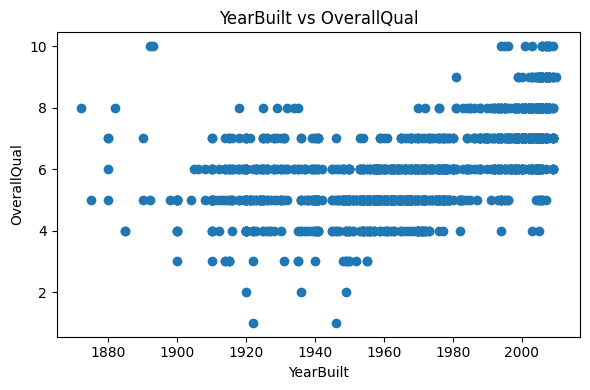

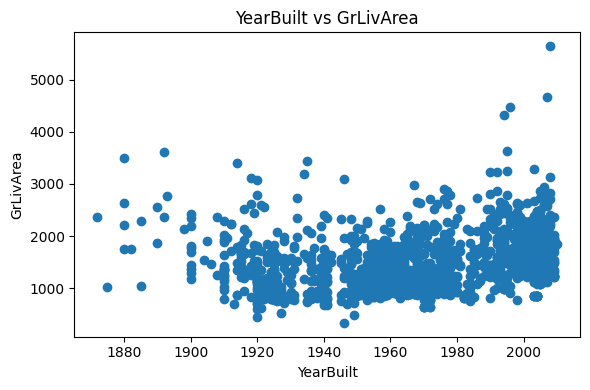

In [29]:
numeric_cols = ["SalePrice" , "OverallQual" , "GrLivArea" , "YearBuilt" ]



for i in range(len(numeric_cols)):
    for j in range(i):

    
      x = numeric_cols[i]
      y = numeric_cols[j]

      plt.figure(figsize=(6,4))
      plt.scatter(data[x], data[y])
      plt.xlabel(x)
      plt.ylabel(y)
      plt.title(f"{x} vs {y}")
      plt.tight_layout()
      plt.show()


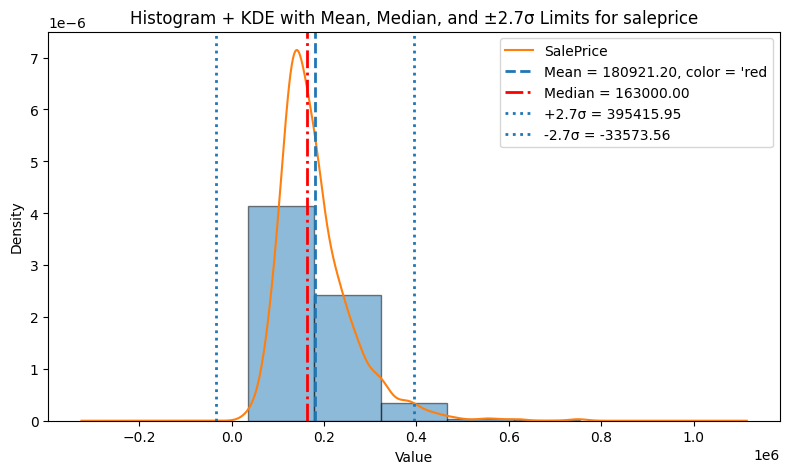

In [54]:
a = data["SalePrice"]

mu = np.mean(a)
sigma = np.std(a, ddof=1)   # sample std deviation

ucl = mu + 2.7 * sigma
lcl = mu - 2.7 * sigma

plt.figure(figsize=(8,5))

plt.hist(a, bins=5, density=True, edgecolor='black', alpha=0.5)
pd.Series(a).plot(kind='kde')

plt.axvline(mu, linestyle='--', linewidth=2, label=f"Mean = {mu:.2f}, color = 'red")
plt.axvline(np.median(a), linestyle='-.', linewidth=2, label=f"Median = {np.median(a):.2f}", color = 'red')

plt.axvline(ucl, linestyle=':', linewidth=2, label=f"+2.7σ = {ucl:.2f}")
plt.axvline(lcl, linestyle=':', linewidth=2, label=f"-2.7σ = {lcl:.2f}")

plt.title('Histogram + KDE with Mean, Median, and ±2.7σ Limits for saleprice')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

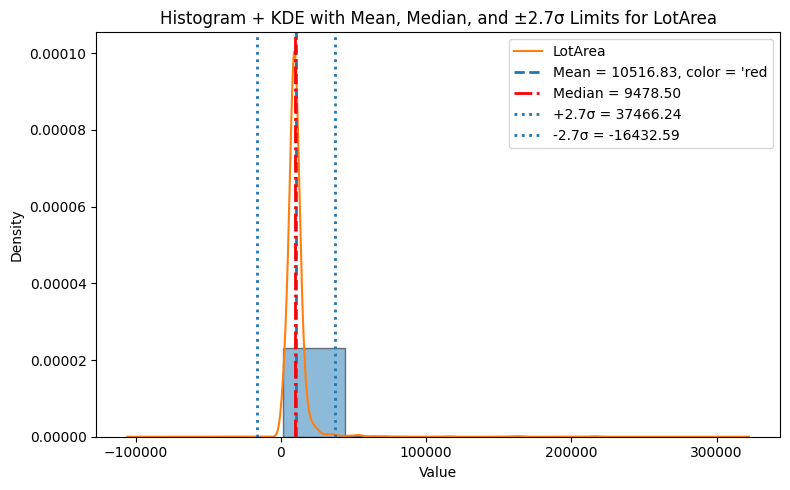

In [55]:
a = data["LotArea"]

mu = np.mean(a)
sigma = np.std(a, ddof=1)   # sample std deviation

ucl = mu + 2.7 * sigma
lcl = mu - 2.7 * sigma

plt.figure(figsize=(8,5))

plt.hist(a, bins=5, density=True, edgecolor='black', alpha=0.5)
pd.Series(a).plot(kind='kde')

plt.axvline(mu, linestyle='--', linewidth=2, label=f"Mean = {mu:.2f}, color = 'red")
plt.axvline(np.median(a), linestyle='-.', linewidth=2, label=f"Median = {np.median(a):.2f}", color = 'red')

plt.axvline(ucl, linestyle=':', linewidth=2, label=f"+2.7σ = {ucl:.2f}")
plt.axvline(lcl, linestyle=':', linewidth=2, label=f"-2.7σ = {lcl:.2f}")

plt.title('Histogram + KDE with Mean, Median, and ±2.7σ Limits for LotArea')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

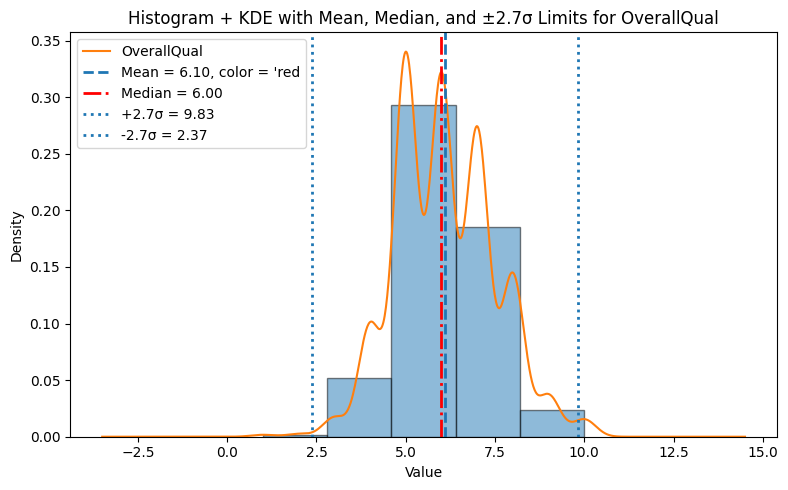

In [56]:
a = data["OverallQual"]

mu = np.mean(a)
sigma = np.std(a, ddof=1)   # sample std deviation

ucl = mu + 2.7 * sigma
lcl = mu - 2.7 * sigma

plt.figure(figsize=(8,5))

plt.hist(a, bins=5, density=True, edgecolor='black', alpha=0.5)
pd.Series(a).plot(kind='kde')

plt.axvline(mu, linestyle='--', linewidth=2, label=f"Mean = {mu:.2f}, color = 'red")
plt.axvline(np.median(a), linestyle='-.', linewidth=2, label=f"Median = {np.median(a):.2f}", color = 'red')

plt.axvline(ucl, linestyle=':', linewidth=2, label=f"+2.7σ = {ucl:.2f}")
plt.axvline(lcl, linestyle=':', linewidth=2, label=f"-2.7σ = {lcl:.2f}")

plt.title('Histogram + KDE with Mean, Median, and ±2.7σ Limits for OverallQual')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

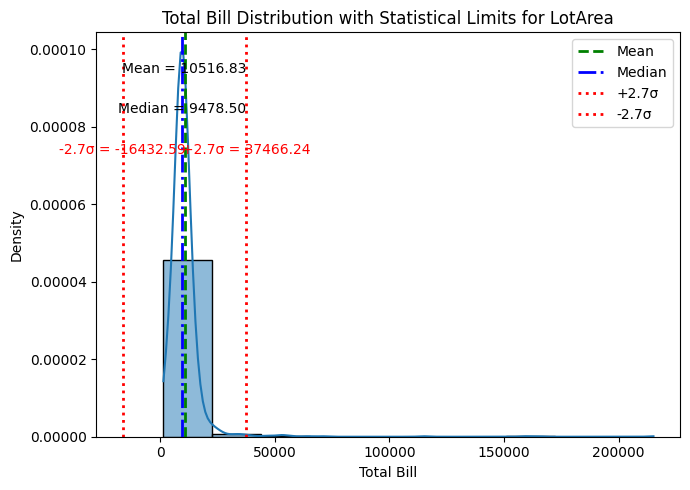

In [11]:
d = data['LotArea'].dropna()

mu = d.mean()
median = d.median()
sigma = d.std(ddof=1)

ucl = mu + 2.7 * sigma
lcl = mu - 2.7 * sigma

plt.figure(figsize=(7,5))
sns.histplot(d, bins=10, kde=True, stat="density")

# Reference lines
plt.axvline(mu, linestyle='--', linewidth=2, label='Mean', color ='green')
plt.axvline(median, linestyle='-.', linewidth=2, label='Median', color = 'blue')
plt.axvline(ucl, linestyle=':', linewidth=2, color='red', label='+2.7σ')
plt.axvline(lcl, linestyle=':', linewidth=2, color='red', label='-2.7σ')

# Numeric labels
ymax = plt.ylim()[1]
plt.text(mu, ymax*0.90, f"Mean = {mu:.2f}", ha='center')
plt.text(median, ymax*0.80, f"Median = {median:.2f}", ha='center')
plt.text(ucl, ymax*0.70, f"+2.7σ = {ucl:.2f}", ha='center', color='red')
plt.text(lcl, ymax*0.70, f"-2.7σ = {lcl:.2f}", ha='center', color='red')

plt.title("Total Bill Distribution with Statistical Limits for LotArea")
plt.xlabel("Total Bill")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

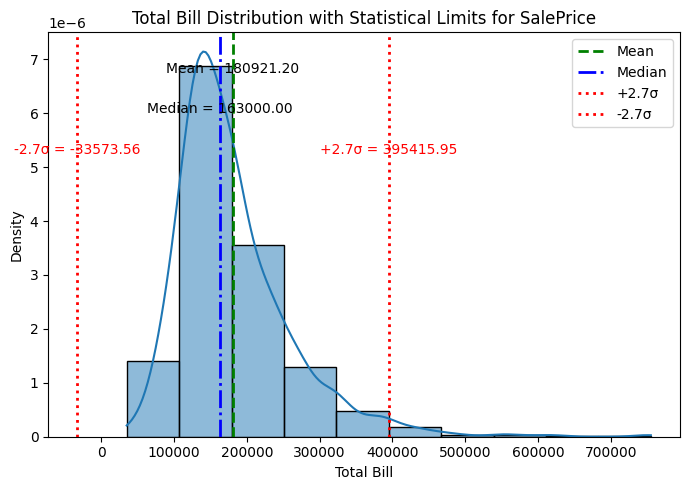

In [12]:
d = data['SalePrice'].dropna()

mu = d.mean()
median = d.median()
sigma = d.std(ddof=1)

ucl = mu + 2.7 * sigma
lcl = mu - 2.7 * sigma

plt.figure(figsize=(7,5))
sns.histplot(d, bins=10, kde=True, stat="density")

# Reference lines
plt.axvline(mu, linestyle='--', linewidth=2, label='Mean', color ='green')
plt.axvline(median, linestyle='-.', linewidth=2, label='Median', color = 'blue')
plt.axvline(ucl, linestyle=':', linewidth=2, color='red', label='+2.7σ')
plt.axvline(lcl, linestyle=':', linewidth=2, color='red', label='-2.7σ')

# Numeric labels
ymax = plt.ylim()[1]
plt.text(mu, ymax*0.90, f"Mean = {mu:.2f}", ha='center')
plt.text(median, ymax*0.80, f"Median = {median:.2f}", ha='center')
plt.text(ucl, ymax*0.70, f"+2.7σ = {ucl:.2f}", ha='center', color='red')
plt.text(lcl, ymax*0.70, f"-2.7σ = {lcl:.2f}", ha='center', color='red')

plt.title("Total Bill Distribution with Statistical Limits for SalePrice")
plt.xlabel("Total Bill")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

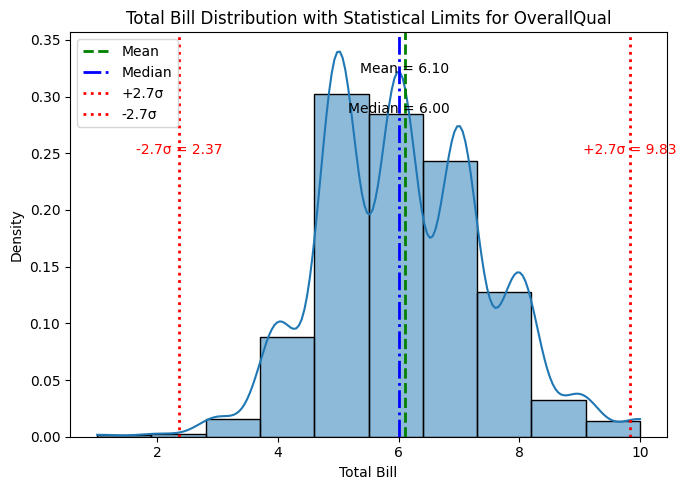

In [13]:
d = data['OverallQual'].dropna()

mu = d.mean()
median = d.median()
sigma = d.std(ddof=1)

ucl = mu + 2.7 * sigma
lcl = mu - 2.7 * sigma

plt.figure(figsize=(7,5))
sns.histplot(d, bins=10, kde=True, stat="density")

# Reference lines
plt.axvline(mu, linestyle='--', linewidth=2, label='Mean', color ='green')
plt.axvline(median, linestyle='-.', linewidth=2, label='Median', color = 'blue')
plt.axvline(ucl, linestyle=':', linewidth=2, color='red', label='+2.7σ')
plt.axvline(lcl, linestyle=':', linewidth=2, color='red', label='-2.7σ')

# Numeric labels
ymax = plt.ylim()[1]
plt.text(mu, ymax*0.90, f"Mean = {mu:.2f}", ha='center')
plt.text(median, ymax*0.80, f"Median = {median:.2f}", ha='center')
plt.text(ucl, ymax*0.70, f"+2.7σ = {ucl:.2f}", ha='center', color='red')
plt.text(lcl, ymax*0.70, f"-2.7σ = {lcl:.2f}", ha='center', color='red')

plt.title("Total Bill Distribution with Statistical Limits for OverallQual")
plt.xlabel("Total Bill")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

             SalePrice  GrLivArea  YearBuilt
OverallQual                                 
1               100300       1238       3868
2               155311       1718       5805
3              1749475      22383      38654
4             12576796     128374     226001
5             53008769     496547     776029
6             60439535     548237     735896
7             66261539     543523     634258
8             46155570     327199     335466
9             15803060      89333      86220
10             7894591      54025      35854


[]

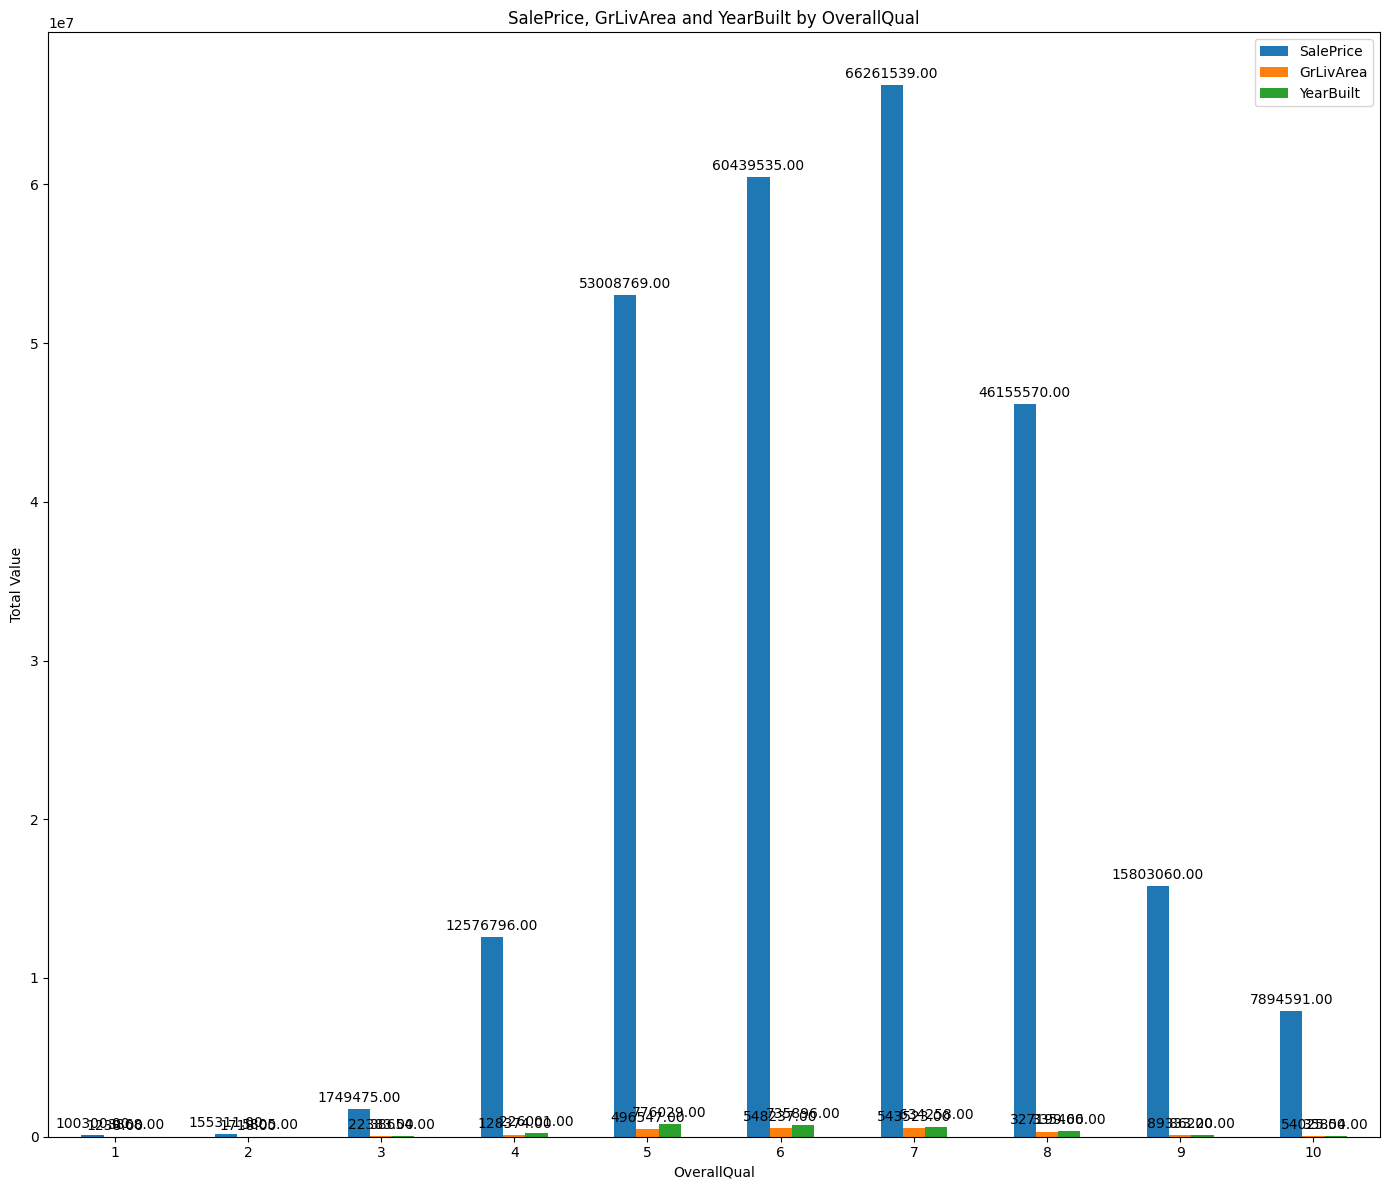

In [15]:
# Plot profit by Category
total_profit = data.groupby('OverallQual')[['SalePrice', 'GrLivArea', 'YearBuilt']].sum()
print(total_profit)


ax = total_profit.plot(kind='bar', figsize=(14,12))
plt.title('SalePrice, GrLivArea and YearBuilt by OverallQual')
plt.xlabel('OverallQual')
plt.ylabel('Total Value')
plt.xticks(rotation=0)

for container in ax.containers: # ax.containers refers to a list of container objects that hold groups of artists (graphical elements) created by certain plotting functions
    ax.bar_label(container, fmt='%.2f', padding=3, rotation = 0)

plt.tight_layout()
plt.plot()


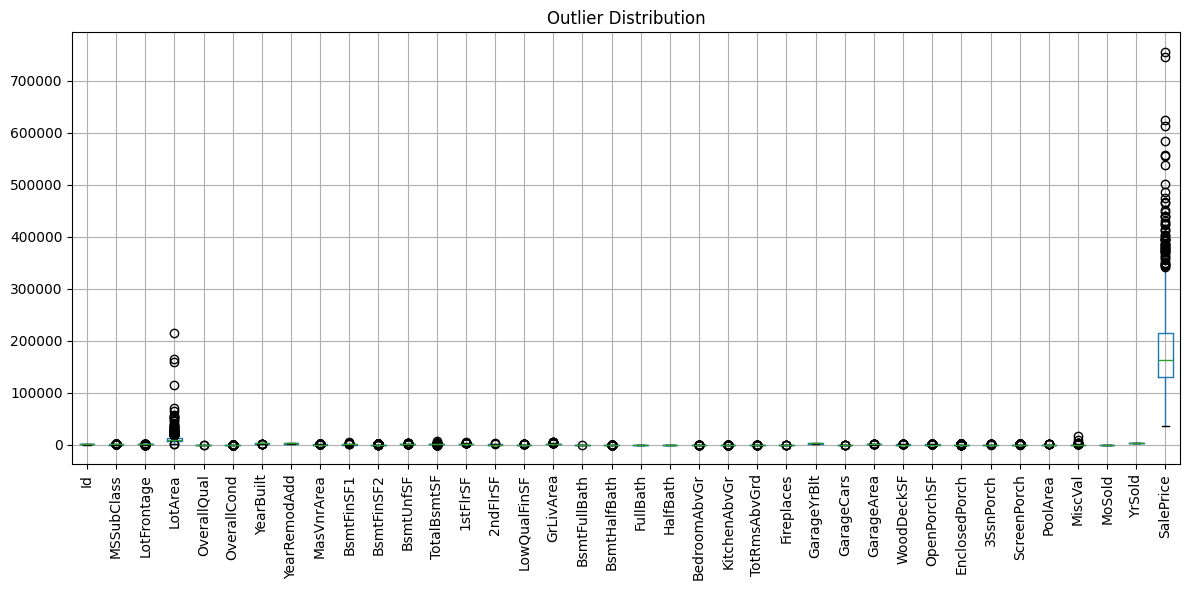

In [16]:
plt.figure(figsize=(12, 6))
numeric_df.boxplot()
plt.title("Outlier Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
sns.boxplot(x='day', y='total_bill', data)
plt.title('Box Plot using Seaborn Day vs Total_bill')
plt.show()